In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any

from src.build_network import ResIN
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
OUTPATH = "../../output/results-summary-082924/"

print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


In [31]:
anes_all = pd.read_csv(ROOTPATH + "data/anes_out_071824.csv").drop(columns=["Unnamed: 0"])
YEARS = [2000, 2004, 2008, 2012, 2016, 2020]
anes_all = anes_all[anes_all["year"].isin(YEARS)]
anes_all["ft_rep_net"] = anes_all["ft_rep"] - anes_all["ft_dem"] # compute the net value of ft rep/dem
# internet access
anes_all["it_access"] = anes_all["it_access"].replace(5, 0)
anes_all["it_access"] = anes_all["it_access"].replace(9, np.NaN)
anes_all.head()


,year,gov_health,guar_jobs,us_isolate,aid_black,abort,spend_serv,def_spend,aff_act_1,aff_act_2,...,hw_whites,hw_blacks,hw_his,hw_asian,it_access,it_campaign,left_right,lbrl_cnsv,weights,ft_rep_net
11295,2000,5.0,6.0,NaN,NaN,2.0,3.0,6.0,5.0,5.0,...,4.0,4.0,4.0,4.0,1.0,1.0,NaN,NaN,1.2886,16.0
11296,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,5.0,4.0,7.0,1.0,1.0,5.0,NaN,NaN,0.8959,NaN
11297,2000,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,...,1.0,1.0,6.0,5.0,1.0,5.0,NaN,NaN,1.0454,-30.0
11298,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,1.0,5.0,4.0,1.0,0.0,5.0,NaN,5.0,0.6005,-5.0
11299,2000,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5.0,5.0,...,2.0,4.0,5.0,1.0,0.0,5.0,NaN,6.0,1.9270,70.0


In [26]:
anes_all.columns

Index(['year', 'gov_health', 'guar_jobs', 'us_isolate', 'aid_black', 'abort',
       'spend_serv', 'def_spend', 'aff_act_1', 'aff_act_2', 'gay_discr',
       'immigrat', 'spend_poor', 'spend_child', 'spend_crime', 'spend_school',
       'spend_welfare', 'spend_env', 'spend_socsec', 'black_fairjob',
       'import_lim', 'death_pen', 'gun_own', 'def_spend_D', 'aid_black_D',
       'gov_health_D', 'spend_serv_D', 'guar_jobs_D', 'lib_con_D', 'abort_D',
       'def_spend_R', 'aid_black_R', 'gov_health_R', 'spend_serv_R',
       'guar_jobs_R', 'lib_con_R', 'abort_R', 'lib_con', 'pid', 'egal_1',
       'egal_2', 'auth_1', 'auth_2', 'auth_3', 'auth_4', 'rac_res_1',
       'rac_res_2', 'rac_res_3', 'rac_res_4', 'penalty_favopp', 'ft_jews',
       'ft_blacks', 'ft_whites', 'ft_bis', 'ft_lab', 'ft_lib', 'ft_con',
       'ft_his', 'ft_dem', 'ft_poor', 'ft_rep', 'ft_asian', 'ft_congr',
       'ft_gay', 'ft_immigr', 'ft_chrfund', 'ft_fem', 'ft_mus', 'ft_chr',
       'hw_whites', 'hw_blacks', 'hw_his

In [30]:
anes_all[anes_all["it_access"].notna()]["year"].unique()

array([2000, 2004, 2008])

In [27]:
anes_all["it_campaign"]

11295    1.0
11296    5.0
11297    5.0
11298    5.0
11299    5.0
        ... 
36606    NaN
36607    NaN
36608    NaN
36609    NaN
36610    NaN
Name: it_campaign, Length: 23805, dtype: float64

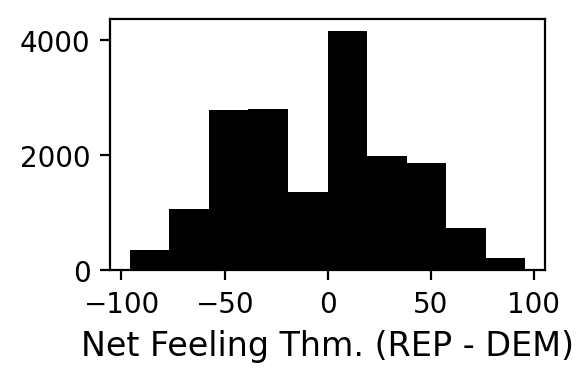

In [3]:
fig,ax = plt.subplots(figsize=(3,2))
plt.hist(anes_all["ft_rep_net"], color="black", bins=10)
plt.xlabel("Net Feeling Thm. (REP - DEM)", fontsize=12)
plt.tight_layout()

In [4]:
NODE_COLS = [
    "spend_serv", "gov_health", "guar_jobs", "aff_act_2", "abort",
    "immigrat", "gun_own", "spend_school", "spend_crime", "spend_welfare",
    "spend_poor", "penalty_favopp", "gay_discr",
    "left_right", "lbrl_cnsv"
]

COV_COLS = ["ft_rep_net"]

In [5]:
RESIN_DICT = {}
NEUTRAL_VAL_DICT = {}
for year in YEARS:
    print("processing:", year)
    anes_year = anes_all[anes_all["year"]==year].copy()
    anes_year = anes_year[NODE_COLS + COV_COLS]
    resin = ResIN(df=anes_year, node_cols=NODE_COLS)
    resin.make_graph(square_corr=False, remove_nan=True)
    resin.compute_covariates(covariate_cols=COV_COLS)
    resin.adjust_coordinates()
    resin.get_item_size()
    resin.set_edge_distance()
    RESIN_DICT[year] = resin
    NEUTRAL_VAL_DICT[year] = np.nanmean(anes_year["ft_rep_net"])

processing: 2000
processing: 2004
processing: 2008
processing: 2012
processing: 2016
processing: 2020


## Network-level metrics

1. Modularity

2. Assortativity

In [6]:
def get_binary_comm(resin, comm_attr):
    comms = [set(), set()]
    for n,v in resin.node_attrs[comm_attr].items():
        if v > 0:
            comms[0].add(n)
        else:
            comms[1].add(n)
    return comms 

modularity_ls = []
comm_attr = "ft_rep_net"
nruns = 10

for year, resin in RESIN_DICT.items():
    comms = get_binary_comm(resin, comm_attr)
    g = resin.g
    mod = nx.community.modularity(g, comms)
    print(year, mod)


2000 0.3724996745565239
2004 0.3823083739222841
2008 0.18749044214079907
2012 0.3872032479644114
2016 0.4444010659138522
2020 0.4578825839711369


In [7]:
modularity_ls_bstr = {}
comm_attr = "ft_rep_net"
nruns = 100

for year in YEARS:
    modularity_ls_bstr[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr = anes_all[anes_all["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr = anes_year_bstr[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        comms = get_binary_comm(resin, comm_attr)
        g = resin.g
        mod = nx.community.modularity(g, comms)
        modularity_ls_bstr[year].append(mod)

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
- run: 16
- run: 17
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
- run: 42
- run: 43
- run: 44
- run: 45
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
- run: 81
- run: 82
- run: 83
- run: 84
- run: 85
- run: 86
- run: 87
- run: 88
- run: 89
- run: 90
- run: 91
- run: 92
- run: 93
- run: 94
- run: 95
- run: 96
- run: 97
- run: 98
- r

In [8]:
def m(x, w):
    """Weighted Mean"""
    return np.sum(x * w) / np.sum(w)

def cov(x, y, w):
    """Weighted Covariance"""
    return np.sum(w * (x - m(x, w)) * (y - m(y, w))) / np.sum(w)

def corr(x, y, w):
    """Weighted Correlation"""
    return cov(x, y, w) / np.sqrt(cov(x, x, w) * cov(y, y, w))

def compute_assortativity(resin, node_attr="ft_rep_net"):
    g = resin.g
    node_attrs = resin.node_attrs[node_attr]
    edge_wghts = nx.get_edge_attributes(g, "weight")
    x = []
    y = []
    w = []
    for n1,n2 in g.edges():
        x.append(node_attrs[n1])
        y.append(node_attrs[n2])
        w.append(edge_wghts[(n1, n2)])
    c = corr(np.array(x), np.array(y), np.array(w))
    return c

for year, resin in RESIN_DICT.items():
    asst = compute_assortativity(resin)
    print(year, asst)

2000 0.6963686475295708
2004 0.7040900234163278
2008 0.6808823873574491
2012 0.793392513200926
2016 0.812917252986808
2020 0.8570027016820101


In [9]:
asst_ls_bstr = {}
comm_attr = "ft_rep_net"
nruns = 100

for year in YEARS:
    asst_ls_bstr[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr = anes_all[anes_all["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr = anes_year_bstr[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        asst = compute_assortativity(resin)
        asst_ls_bstr[year].append(asst)

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
- run: 16
- run: 17
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
- run: 42
- run: 43
- run: 44
- run: 45
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
- run: 81
- run: 82
- run: 83
- run: 84
- run: 85
- run: 86
- run: 87
- run: 88
- run: 89
- run: 90
- run: 91
- run: 92
- run: 93
- run: 94
- run: 95
- run: 96
- run: 97
- run: 98
- r

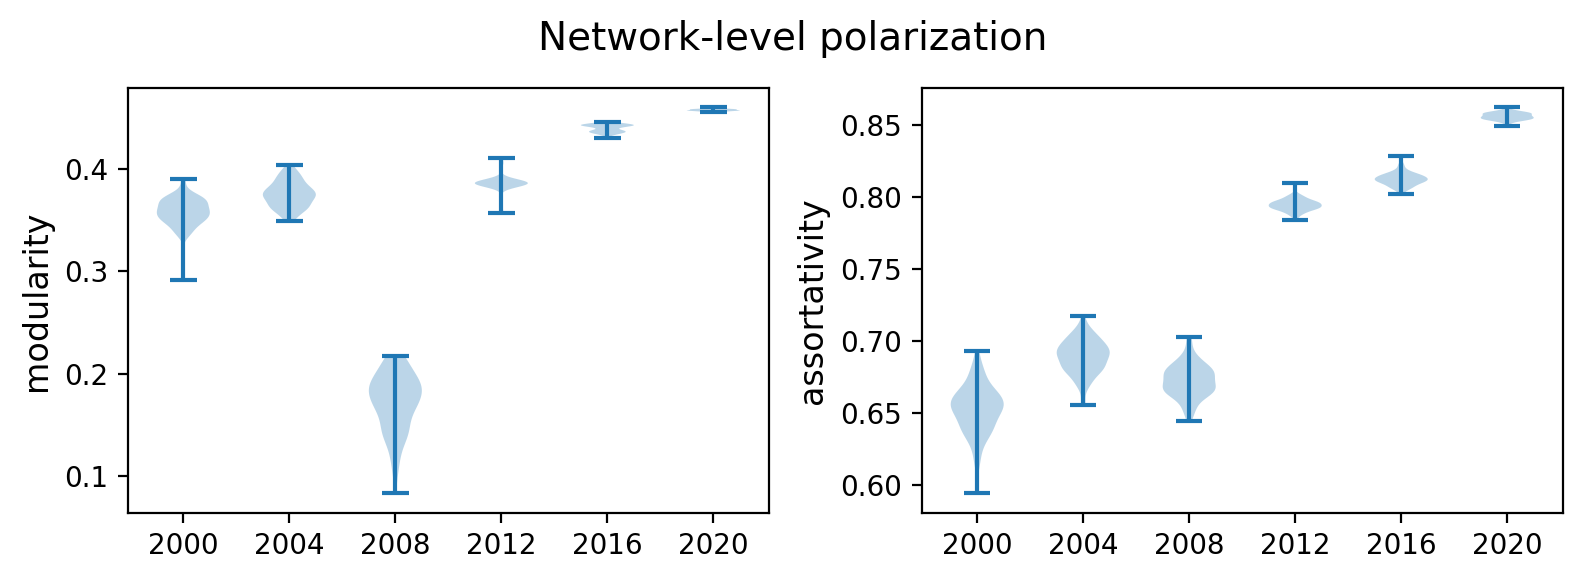

In [23]:
fig,ax = plt.subplots(ncols=2, figsize=(8,3))
# ax[0].boxplot(modularity_ls_bstr.values(), sym="+")
# ax[1].boxplot(asst_ls_bstr.values(), sym="+")
ax[0].violinplot(modularity_ls_bstr.values())
ax[1].violinplot(asst_ls_bstr.values())
ax[0].set_ylabel("modularity", fontsize=12)
ax[1].set_ylabel("assortativity", fontsize=12)
for i in [0,1]:
    ax[i].set_xticks(range(1,7), YEARS)
plt.suptitle("Network-level polarization", fontsize=14, y=.95)
plt.tight_layout()
# plt.show()
plt.savefig(OUTPATH + "network-level-polar.png", dpi=300, bbox_inches="tight")

### Network-level metrics for online/offline population

In [32]:
anes_on = anes_all[anes_all["it_access"]==1]
anes_off = anes_all[anes_all["it_access"]==0]

In [33]:
asst_ls_bstr_on = {}
comm_attr = "ft_rep_net"
nruns = 100

for year in [2000, 2004, 2008]:
    asst_ls_bstr_on[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr_on = anes_on[anes_on["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr_on = anes_year_bstr_on[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr_on, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        asst = compute_assortativity(resin)
        asst_ls_bstr_on[year].append(asst)

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
- run: 16
- run: 17
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
- run: 42
- run: 43
- run: 44
- run: 45
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
- run: 81
- run: 82
- run: 83
- run: 84
- run: 85
- run: 86
- run: 87
- run: 88
- run: 89
- run: 90
- run: 91
- run: 92
- run: 93
- run: 94
- run: 95
- run: 96
- run: 97
- run: 98
- r

In [34]:
asst_ls_bstr_off = {}
comm_attr = "ft_rep_net"
nruns = 100

for year in [2000, 2004, 2008]:
    asst_ls_bstr_off[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr_off = anes_off[anes_off["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr_off = anes_year_bstr_off[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr_off, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        asst = compute_assortativity(resin)
        asst_ls_bstr_off[year].append(asst)

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
lbrl_cnsv:1.0
- run: 16
- run: 17
lbrl_cnsv:1.0
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
lbrl_cnsv:1.0
- run: 33
lbrl_cnsv:1.0
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
lbrl_cnsv:1.0
- run: 42
- run: 43
lbrl_cnsv:1.0
- run: 44
- run: 45
- run: 46
lbrl_cnsv:1.0
- run: 47
- run: 48
- run: 49
lbrl_cnsv:1.0
- run: 50
lbrl_cnsv:1.0
- run: 51
lbrl_cnsv:1.0
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
lbrl_cnsv:1.0
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
lbrl_cnsv:1.0
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
lbrl_cnsv:1.0
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
-

In [61]:
modularity_ls_bstr_on = {}
comm_attr = "ft_rep_net"
nruns = 100

for year in [2000, 2004, 2008]:
    modularity_ls_bstr_on[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr_on = anes_on[anes_on["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr_on = anes_year_bstr_on[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr_on, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        comms = get_binary_comm(resin, comm_attr)
        g = resin.g
        mod = nx.community.modularity(g, comms)
        modularity_ls_bstr_on[year].append(mod)

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
- run: 16
- run: 17
- run: 18
- run: 19
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
- run: 25
- run: 26
- run: 27
- run: 28
- run: 29
- run: 30
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
- run: 37
- run: 38
- run: 39
- run: 40
- run: 41
- run: 42
- run: 43
- run: 44
- run: 45
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
- run: 53
- run: 54
- run: 55
- run: 56
- run: 57
- run: 58
- run: 59
- run: 60
- run: 61
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
- run: 68
- run: 69
- run: 70
- run: 71
- run: 72
- run: 73
- run: 74
- run: 75
- run: 76
- run: 77
- run: 78
- run: 79
- run: 80
- run: 81
- run: 82
- run: 83
- run: 84
- run: 85
- run: 86
- run: 87
- run: 88
- run: 89
- run: 90
- run: 91
- run: 92
- run: 93
- run: 94
- run: 95
- run: 96
- run: 97
- run: 98
- r

In [62]:
modularity_ls_bstr_off = {}
comm_attr = "ft_rep_net"
nruns = 100

for year in [2000, 2004, 2008]:
    modularity_ls_bstr_off[year] = []
    print("processing:", year)
    for r in range(nruns):
        print("- run:", r)
        anes_year_bstr_off = anes_off[anes_off["year"]==year].sample(frac=.8, replace=False).copy()
        anes_year_bstr_off = anes_year_bstr_off[NODE_COLS + COV_COLS]
        resin = ResIN(df=anes_year_bstr_off, node_cols=NODE_COLS)
        resin.make_graph(square_corr=False, remove_nan=True)
        resin.compute_covariates(covariate_cols=COV_COLS)
        comms = get_binary_comm(resin, comm_attr)
        g = resin.g
        mod = nx.community.modularity(g, comms)
        modularity_ls_bstr_off[year].append(mod)

processing: 2000
- run: 0
- run: 1
- run: 2
- run: 3
- run: 4
- run: 5
- run: 6
- run: 7
- run: 8
- run: 9
- run: 10
lbrl_cnsv:1.0
- run: 11
- run: 12
- run: 13
- run: 14
- run: 15
lbrl_cnsv:1.0
- run: 16
lbrl_cnsv:1.0
- run: 17
- run: 18
- run: 19
lbrl_cnsv:1.0
- run: 20
- run: 21
- run: 22
- run: 23
- run: 24
lbrl_cnsv:1.0
- run: 25
- run: 26
lbrl_cnsv:1.0
- run: 27
- run: 28
- run: 29
lbrl_cnsv:1.0
- run: 30
lbrl_cnsv:1.0
- run: 31
- run: 32
- run: 33
- run: 34
- run: 35
- run: 36
lbrl_cnsv:1.0
- run: 37
- run: 38
lbrl_cnsv:1.0
- run: 39
- run: 40
- run: 41
lbrl_cnsv:1.0
- run: 42
lbrl_cnsv:1.0
- run: 43
- run: 44
- run: 45
lbrl_cnsv:1.0
- run: 46
- run: 47
- run: 48
- run: 49
- run: 50
- run: 51
- run: 52
lbrl_cnsv:1.0
- run: 53
- run: 54
- run: 55
- run: 56
lbrl_cnsv:1.0
- run: 57
lbrl_cnsv:1.0
- run: 58
lbrl_cnsv:1.0
- run: 59
lbrl_cnsv:1.0
- run: 60
- run: 61
lbrl_cnsv:1.0
- run: 62
- run: 63
- run: 64
- run: 65
- run: 66
- run: 67
lbrl_cnsv:1.0
- run: 68
- run: 69
- run: 70
- r

In [54]:
def clean_nan(arr):
    clean_arr = []
    for vals in arr:
        filter_arr = [x for x in vals if str(x)!="nan"]
        clean_arr.append(filter_arr)
    return clean_arr 

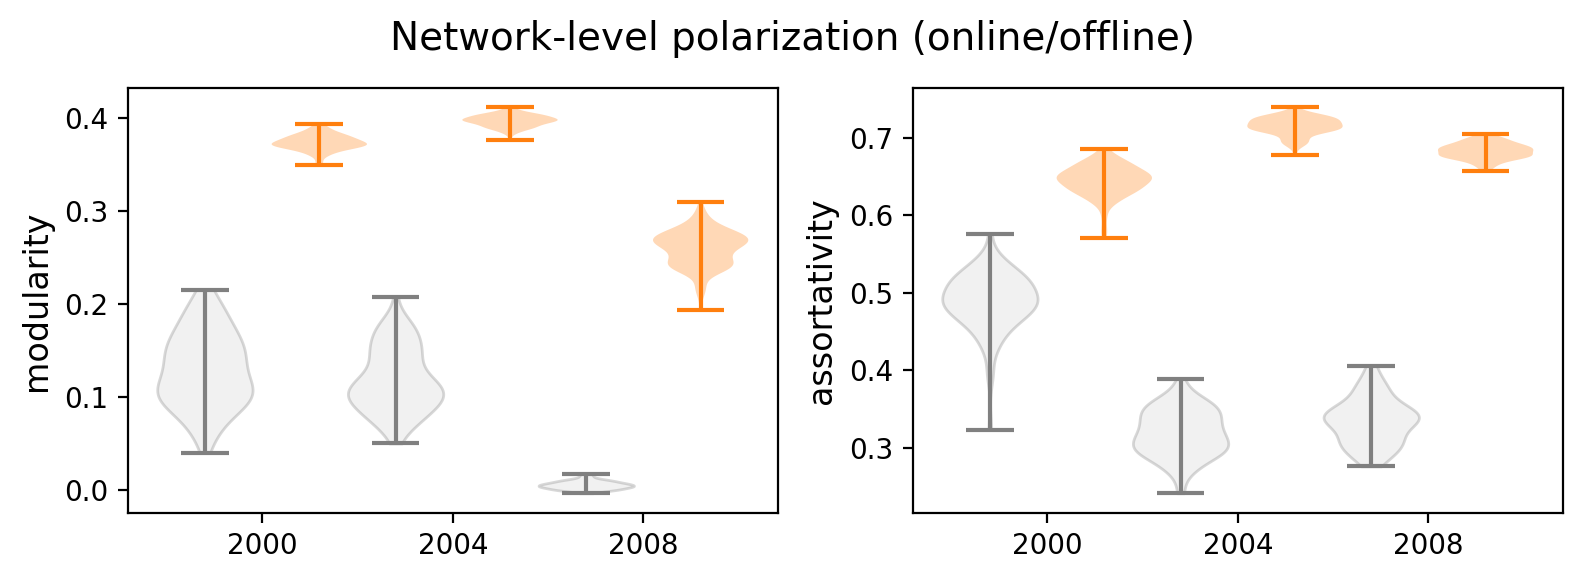

In [66]:
fig,ax = plt.subplots(ncols=2, figsize=(8,3))
vp00 = ax[0].violinplot(clean_nan(modularity_ls_bstr_off.values()), positions=np.arange(1,4)-.3)
vp01 = ax[0].violinplot(clean_nan(modularity_ls_bstr_on.values()), positions=np.arange(1,4)+.3)
vp10 = ax[1].violinplot(clean_nan(asst_ls_bstr_off.values()), positions=np.arange(1,4)-.3)
vp11 = ax[1].violinplot(clean_nan(asst_ls_bstr_on.values()), positions=np.arange(1,4)+.3)
for vp in [vp00, vp10]:
    for pc in vp["bodies"]:
        pc.set_facecolor("lightgrey")
        pc.set_edgecolor("grey")
    for elem in ("cbars","cmins","cmaxes"):
        vp[elem].set_edgecolor("grey")
        
ax[0].set_ylabel("modularity", fontsize=12)
ax[1].set_ylabel("assortativity", fontsize=12)
for i in [0,1]:
    ax[i].set_xticks(range(1,4), [2000, 2004, 2008])
plt.suptitle("Network-level polarization (online/offline)", fontsize=14, y=.95)
plt.tight_layout()
# plt.show()
plt.savefig(OUTPATH + "network-level-polar-ONOFFLINE.png", dpi=300, bbox_inches="tight")

## Node-level metrics

1. Degree centrality

2. Betweenness centrality

In [10]:
# set edge attribute: 1_weight for closeness calculation
def set_edge_distance(g):
    ds = {}
    for e in g.edges(data=True):
        w = e[2]["weight"]
        ds[(e[0],e[1])] = 1-w
    nx.set_edge_attributes(g, ds, "distance")

def get_centrality_df(g):
    df = pd.DataFrame()
    df["node"] = list(g.nodes())
    df["strength"] = [x[1] for x in nx.degree(g, weight="weight")]
    df["betweenness"] = dict(nx.betweenness_centrality(g, weight="distance")).values()
    df["closeness"] = dict(nx.closeness_centrality(g, distance="distance")).values()
    return df

cent_df_all = pd.DataFrame()
for year,resin in RESIN_DICT.items():
    g = resin.g
    set_edge_distance(g)
    cent_df = get_centrality_df(g)
    cent_df = cent_df.melt(id_vars="node", value_vars=["strength", "betweenness", "closeness"])
    cent_df["year"] = year 
    cent_df_all = pd.concat([cent_df, cent_df_all])
cent_df_all

,node,variable,value,year
0,penalty_favopp:2.0,strength,1.278460,2020
1,spend_welfare:2.0,strength,2.089559,2020
2,guar_jobs:6.0,strength,3.122213,2020
3,left_right:9.0,strength,2.476351,2020
4,gov_health:3.0,strength,1.647849,2020
...,...,...,...,...
178,lbrl_cnsv:1.0,closeness,0.687499,2000
179,aff_act_2:1.0,closeness,0.684928,2000
180,guar_jobs:1.0,closeness,0.669938,2000
181,spend_crime:1.0,closeness,0.711749,2000
